# Customer Segmentation Analysis

This notebook generates a synthetic customer dataset, performs clustering using K-Means, and analyzes segment characteristics based on behavior and demographics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', palette='muted')
pd.options.display.max_columns = None

In [2]:
# Generate a synthetic customer dataset
rng = np.random.default_rng(2026)
n_customers = 200
ages = rng.integers(18, 70, size=n_customers)
genders = rng.choice(['Male', 'Female'], size=n_customers, p=[0.48, 0.52])
income = rng.normal(65000, 25000, size=n_customers).clip(18000, 160000).round(0)
purchases_per_month = rng.poisson(3.5, size=n_customers).clip(1, 12)
avg_order_value = (rng.normal(80, 35, size=n_customers) + 0.5 * purchases_per_month).clip(10, 320).round(2)
spend_score = rng.integers(20, 100, size=n_customers)
tenure_months = rng.integers(2, 120, size=n_customers)
loyalty_score = np.clip((0.45 * tenure_months + 0.35 * spend_score + rng.normal(0, 10, n_customers)), 10, 100).round(1)
recency_days = rng.integers(1, 90, size=n_customers)
product_category = rng.choice(['Electronics', 'Apparel', 'Home & Garden', 'Beauty', 'Sports'], size=n_customers, p=[0.22, 0.28, 0.2, 0.16, 0.14])

customers = pd.DataFrame({
    'CustomerID': np.arange(1, n_customers + 1),
    'Age': ages,
    'Gender': genders,
    'AnnualIncome': income,
    'PurchasesPerMonth': purchases_per_month,
    'AvgOrderValue': avg_order_value,
    'SpendScore': spend_score,
    'TenureMonths': tenure_months,
    'LoyaltyScore': loyalty_score,
    'RecencyDays': recency_days,
    'ProductCategory': product_category
})
customers.head()

,CustomerID,Age,Gender,AnnualIncome,PurchasesPerMonth,AvgOrderValue,SpendScore,TenureMonths,LoyaltyScore,RecencyDays,ProductCategory
0,1,62,Female,124013.0,1,64.66,39,25,10.0,61,Electronics
1,2,27,Male,89472.0,2,115.54,70,97,74.3,61,Apparel
2,3,19,Female,69307.0,5,123.45,68,65,44.3,52,Electronics
3,4,51,Male,66436.0,4,90.46,58,4,21.7,21,Electronics
4,5,37,Female,76274.0,8,107.81,67,8,12.4,22,Beauty


In [3]:
customers.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,NaN,NaN,NaN,43.55,14.760994,18.0,32.0,43.0,55.25,69.0
Gender,200,2,Female,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnnualIncome,200.0,NaN,NaN,NaN,65768.565,24598.276348,18000.0,48076.5,66410.5,81088.5,139109.0
PurchasesPerMonth,200.0,NaN,NaN,NaN,3.79,2.113821,1.0,2.0,4.0,5.0,11.0
AvgOrderValue,200.0,NaN,NaN,NaN,79.0421,34.44969,10.0,53.935,79.32,105.685,192.27
SpendScore,200.0,NaN,NaN,NaN,58.14,22.263168,20.0,40.75,54.0,77.25,99.0
TenureMonths,200.0,NaN,NaN,NaN,58.23,33.598981,2.0,29.75,58.5,84.0,119.0
LoyaltyScore,200.0,NaN,NaN,NaN,45.529,19.844822,10.0,33.45,43.55,59.6,100.0
RecencyDays,200.0,NaN,NaN,NaN,46.295,26.54186,1.0,22.0,48.5,71.0,89.0


## Preprocessing and Feature Selection

We create a pipeline to scale numerical features and one-hot encode categorical fields for clustering.

In [4]:
features = ['Age', 'Gender', 'AnnualIncome', 'PurchasesPerMonth', 'AvgOrderValue', 'SpendScore', 'TenureMonths', 'LoyaltyScore', 'RecencyDays', 'ProductCategory']
numeric_features = ['Age', 'AnnualIncome', 'PurchasesPerMonth', 'AvgOrderValue', 'SpendScore', 'TenureMonths', 'LoyaltyScore', 'RecencyDays']
categorical_features = ['Gender', 'ProductCategory']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
], remainder='drop')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
])

X = pipeline.fit_transform(customers[features])
X.shape

(200, 13)

## Finding the Best Number of Segments

We evaluate different values of `k` using the elbow method and silhouette score.

In [5]:
inertia = []
silhouette = []
k_candidates = range(2, 8)

for k in k_candidates:
    model = KMeans(n_clusters=k, random_state=2026, n_init=10)
    labels = model.fit_predict(X)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X, labels))

results = pd.DataFrame({'k': list(k_candidates), 'Inertia': inertia, 'Silhouette': silhouette})
results

,k,Inertia,Silhouette
0,2,1495.868790,0.138949
1,3,1379.193296,0.118658
2,4,1280.968004,0.114720
3,5,1205.440163,0.109734
4,6,1142.459833,0.108145
5,7,1101.565263,0.104129


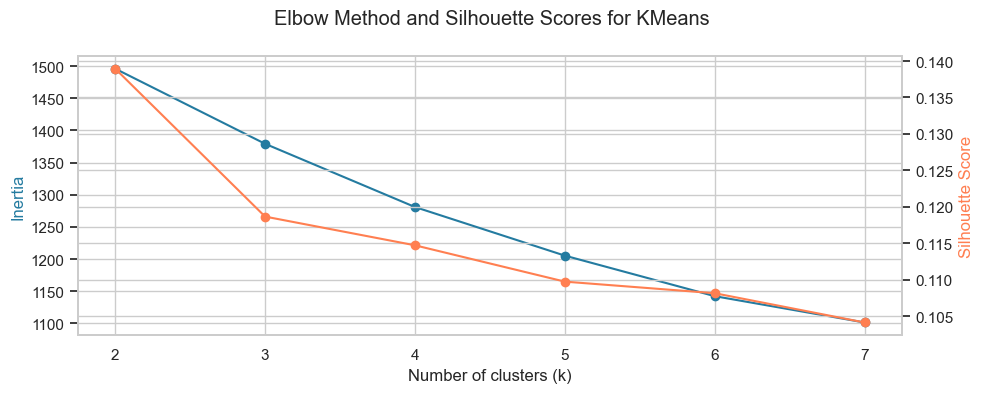

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(results['k'], results['Inertia'], marker='o', label='Inertia', color='#247ba0')
ax2.plot(results['k'], results['Silhouette'], marker='o', label='Silhouette', color='#ff7f51')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='#247ba0')
ax2.set_ylabel('Silhouette Score', color='#ff7f51')
ax1.set_xticks(results['k'])
fig.suptitle('Elbow Method and Silhouette Scores for KMeans')
fig.tight_layout()
plt.show()

## Apply K-Means and Profile Segments

Based on the analysis, we choose a good value of `k`. Typically `k=4` or `k=5` works for this synthetic dataset.

In [7]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=2026, n_init=20)
customers['Segment'] = kmeans.fit_predict(X)
customers['Segment'] = customers['Segment'].astype('category')
customers['Segment'].value_counts().sort_index()

Segment
0    61
1    49
2    33
3    57
Name: count, dtype: int64

In [8]:
segment_profile = customers.groupby('Segment').agg({
    'Age': ['mean', 'min', 'max'],
    'AnnualIncome': ['mean', 'min', 'max'],
    'PurchasesPerMonth': 'mean',
    'AvgOrderValue': 'mean',
    'SpendScore': 'mean',
    'TenureMonths': 'mean',
    'LoyaltyScore': 'mean',
    'RecencyDays': 'mean',
    'CustomerID': 'count'
}).round(2)
segment_profile.columns = ['_'.join(col).strip() for col in segment_profile.columns.values]
segment_profile = segment_profile.rename(columns={'CustomerID_count': 'Count'})
segment_profile

,Age_mean,Age_min,Age_max,AnnualIncome_mean,AnnualIncome_min,AnnualIncome_max,PurchasesPerMonth_mean,AvgOrderValue_mean,SpendScore_mean,TenureMonths_mean,LoyaltyScore_mean,RecencyDays_mean,Count
Segment,,,,,,,,,,,,,
0,52.49,22,69,71843.21,18000.0,139109.0,2.89,63.71,49.16,38.92,32.91,30.95,61
1,35.51,18,66,65439.94,18000.0,115581.0,4.73,94.14,56.29,33.10,30.34,64.22,49
2,32.58,18,67,55233.24,18000.0,91690.0,4.91,90.67,47.61,89.70,57.53,25.55,33
3,47.25,23,68,65649.53,18000.0,113213.0,3.30,75.74,75.44,82.28,65.15,59.32,57


## Visualizing Customer Segments

We visualize purchase behavior, income distribution, and segment sizes.

C:\Users\nethi\AppData\Local\Temp\ipykernel_7968\1376292059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customers, x='Segment', palette='Set2')


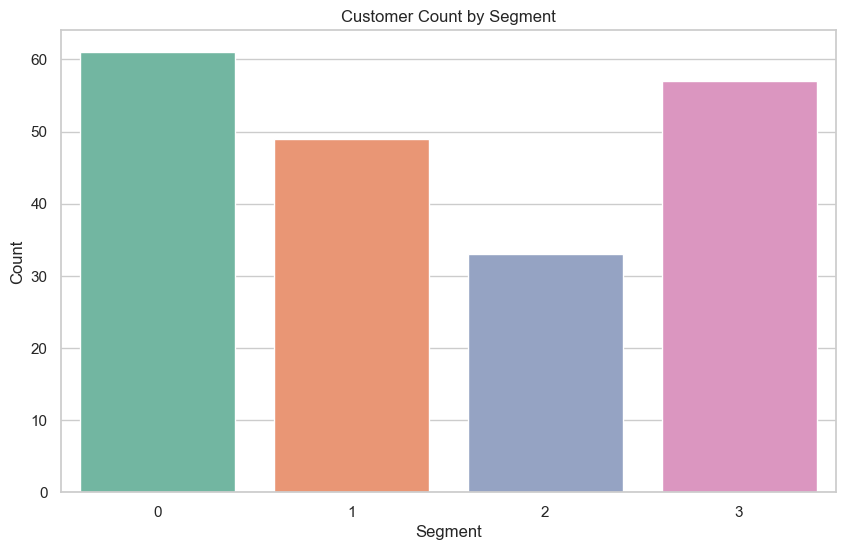

C:\Users\nethi\AppData\Local\Temp\ipykernel_7968\1376292059.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customers, x='Segment', y='AnnualIncome', palette='Set2')


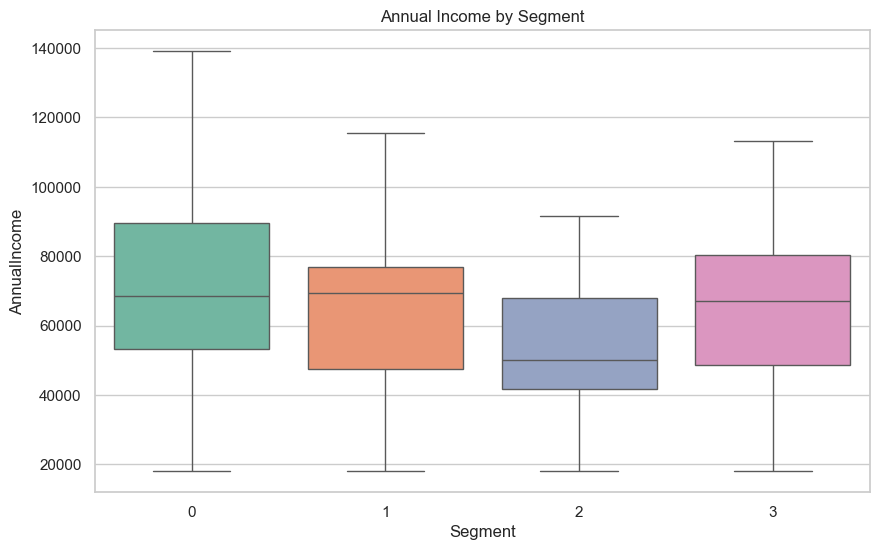

C:\Users\nethi\AppData\Local\Temp\ipykernel_7968\1376292059.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customers, x='Segment', y='SpendScore', palette='Set2')


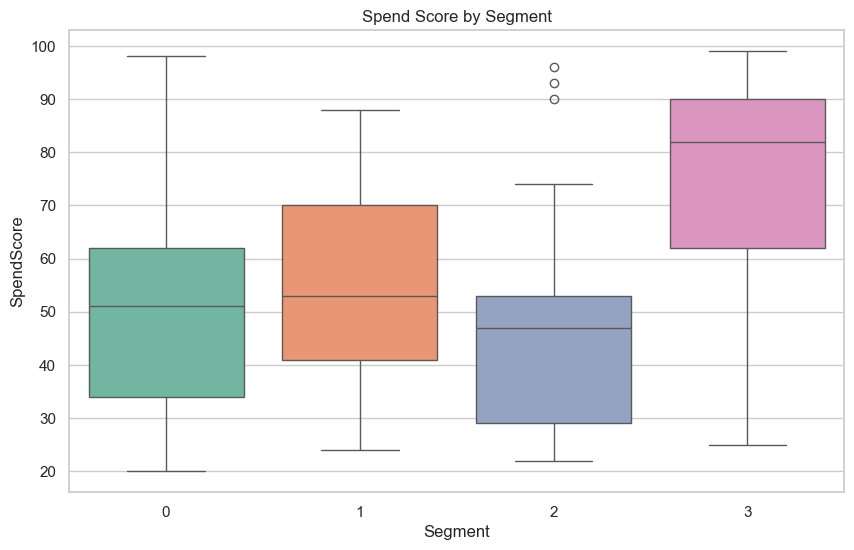

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=customers, x='Segment', palette='Set2')
plt.title('Customer Count by Segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=customers, x='Segment', y='AnnualIncome', palette='Set2')
plt.title('Annual Income by Segment')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=customers, x='Segment', y='SpendScore', palette='Set2')
plt.title('Spend Score by Segment')
plt.show()

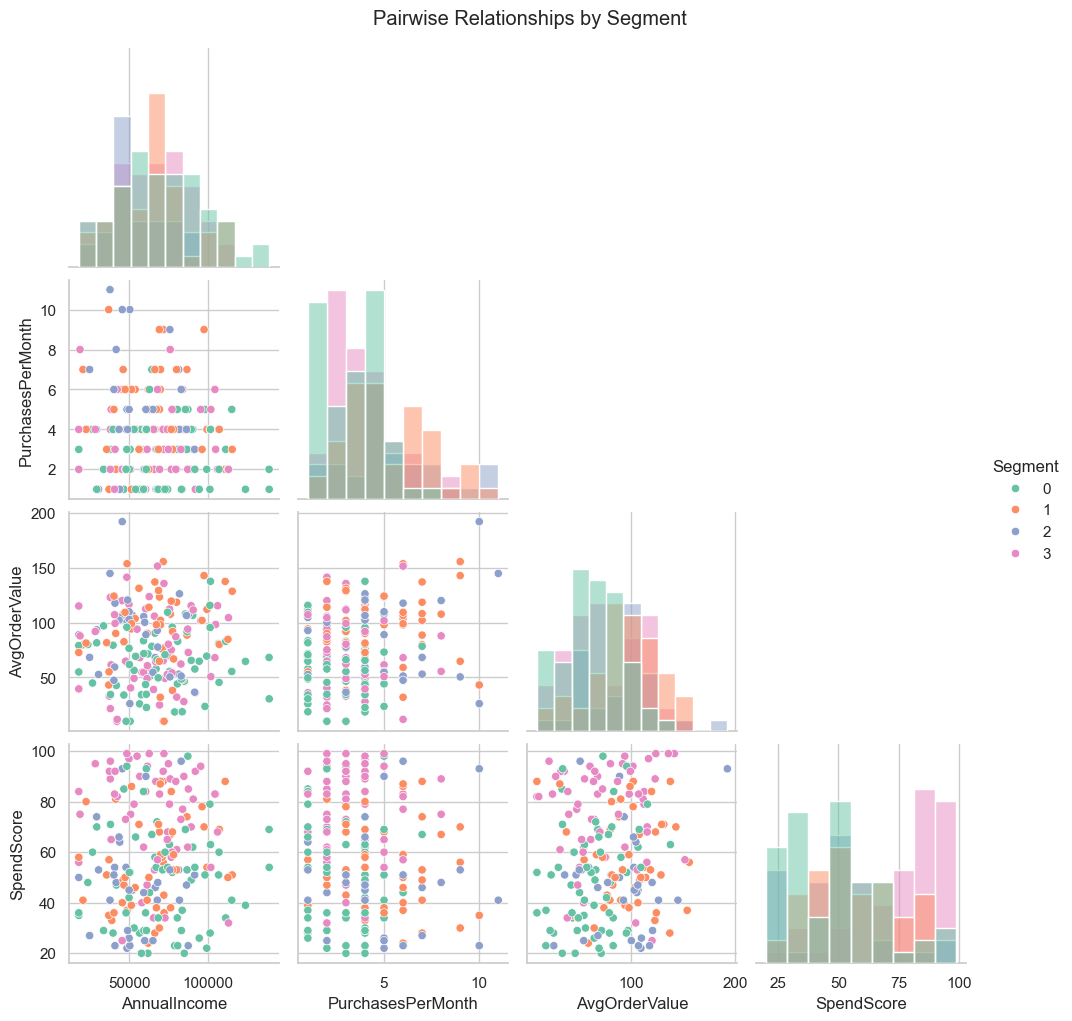

In [10]:
pair_features = ['AnnualIncome', 'PurchasesPerMonth', 'AvgOrderValue', 'SpendScore']
sns.pairplot(customers, vars=pair_features, hue='Segment', palette='Set2', diag_kind='hist', corner=True)
plt.suptitle('Pairwise Relationships by Segment', y=1.02)
plt.show()

## Summary and Insights

This segmentation approach reveals customer groups that differ by income, purchase frequency, average order value, and loyalty. Use these segments for targeted campaigns, personalized offers, and product recommendations.